<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Toxic_Text_Classification_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [201]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [263]:
import pandas as pd
import tensorflow as tf
import numpy as np

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)

In [204]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [205]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [206]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [207]:
import string
nltk.download('omw-1.4')

sns.set_theme(style='whitegrid')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [208]:
import re
from collections import Counter

# Load dataset
from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


In [209]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

In [210]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [211]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()

Train data size and trained data

In [212]:
print(train_df.shape)
print(train_df.head())

(159571, 8)
                 id  \
0  0000997932d777bf   
1  000103f0d9cfb60f   
2  000113f07ec002fd   
3  0001b41b1c6bb37e   
4  0001d958c54c6e35   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         comment_text  \
0                                                                                                                                                                                                                       

In [213]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [214]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [215]:
print('\nMissing values:\n', train_df.isnull().sum())


Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Test data size and test data

In [216]:
print(test_df.shape)
print(test_df.head())

(306328, 8)
                 id  \
0  00001cee341fdb12   
1  0000247867823ef7   
2  00013b17ad220c46   
3  00017563c3f7919a   
4  00017695ad8997eb   

                                                                                                                                                                                                                                                                                                                                                                      comment_text  \
0  Yo bitch Ja Rule is more succesful then you'll ever be whats up with you and hating you sad mofuckas...i should bitch slap ur pethedic white faces and get you to kiss my ass you guys sicken me. Ja rule is about pride in da music man. dont diss that shit on him. and nothin is wrong bein like tupac he was a brother too...fuckin white boys get things right next time.,   
1                                                                                                    

**Binary 'any_toxic' column **




In [217]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


In [218]:
# print(f'Total comments : {len(df):,}')
# print(f'Total toxic comments : {len(train_df[train_df.any_toxic == 1]):,}')
# print(f'Total non-toxic comments : {len(train_df[train_df.any_toxic == 0]):,}')

# Exploratory Data Analysis (EDA)

In [219]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


Bar Chart of Number of Comments per Toxicity Label \
A pie chart for non-toxic vs toxic

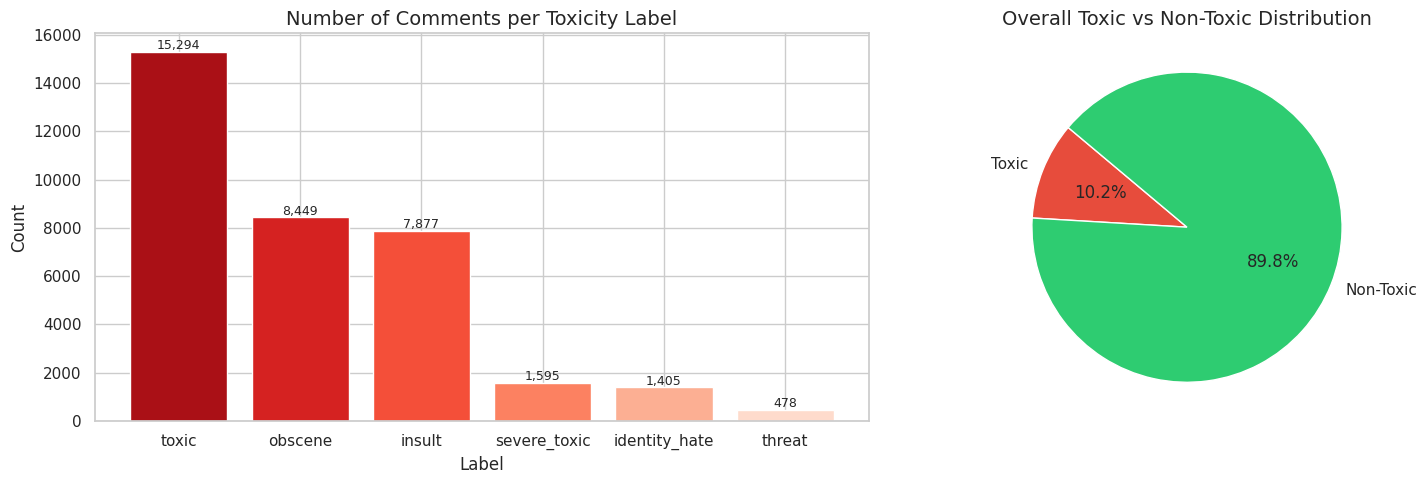

In [220]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



In [221]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

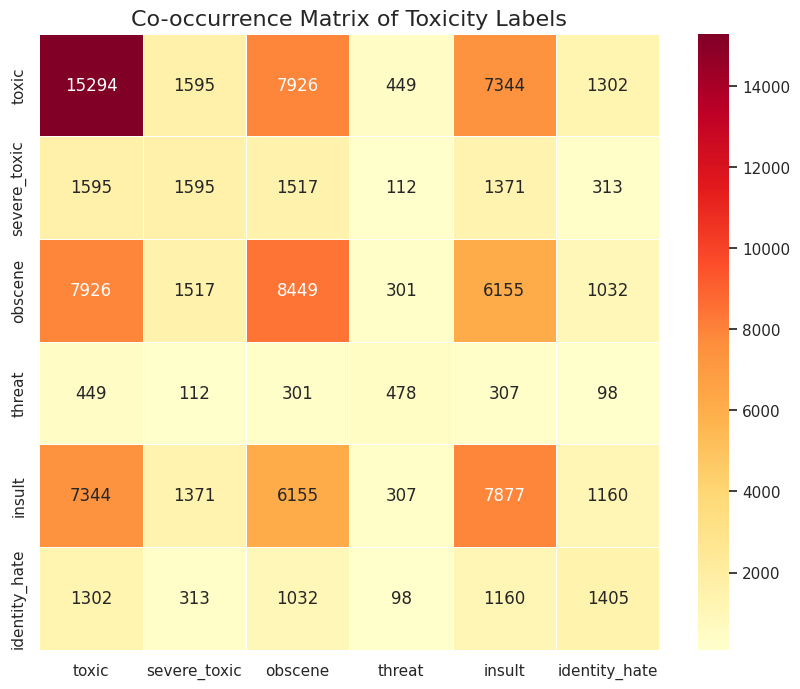

In [222]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


Word Cloud

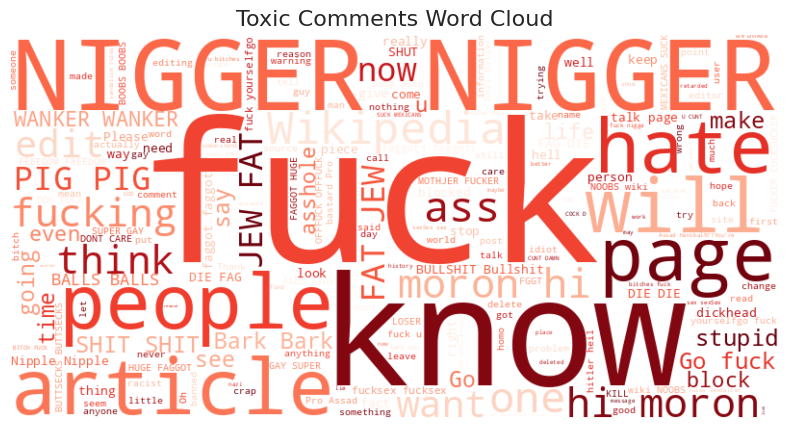

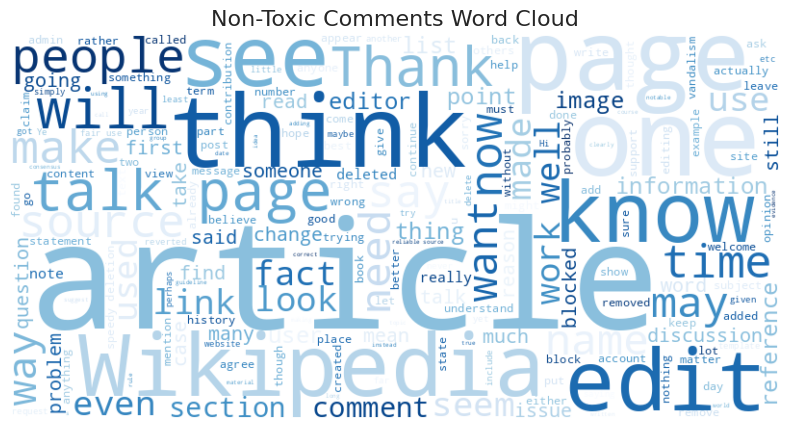

In [223]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

Most frequent words and phrases in toxic comments.
*   Unigrams → single words
*   Bigrams → two-word combinations

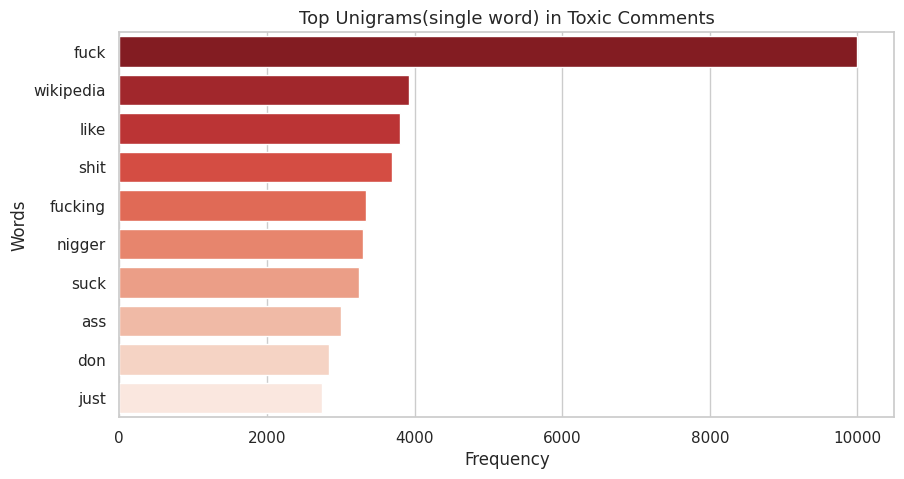

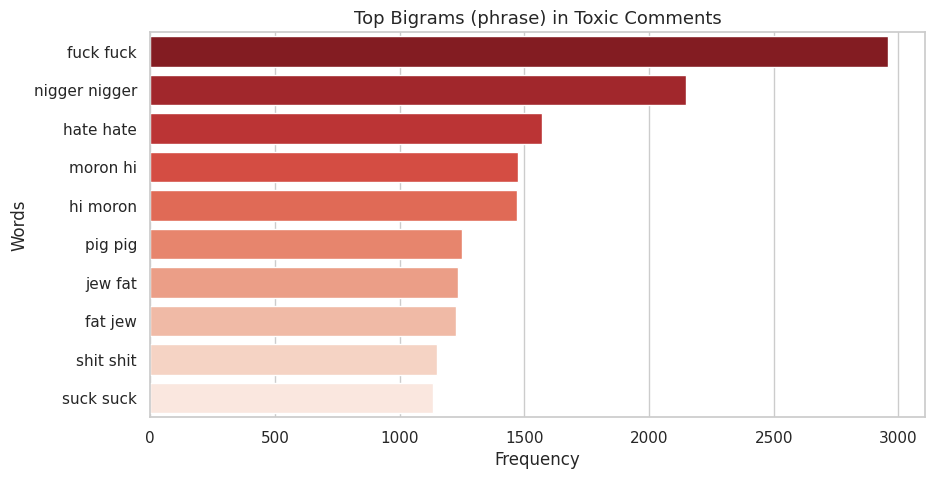

In [224]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# PreProcessing

**Raw data from the trained dataset before any
pre processing **

In [225]:
train_df[['comment_text', "toxic"]].sample(6)

,comment_text,toxic
146156,"Thank you so much Mr. Bot! You're really helpful. But boy, do I feel bad for you! I mean, you have the worst job any robot could have! There's no dignity in your profession! I mean, the AIs in video games have a much high level of respect for you. I bet over here you're trashed left and right by angry WikiVandals! Maybe you should consider working as an AI. I heard there's a lot of job opportunities in that field ;)\n\nLove,\nYayha Al-Shiddazi (WikiVandal)",0
78232,'D.S. is a Song By Michael Jackson\n',0
30076,"HENCE, ROZ LIPSHITS IS AN IDIOT!!!!",1
51915,"Kosova was NEVER Serbia \n\nLook, if Kosova was in Serbia, Serbia would have never invaded it, and the west would not have driven them out would they. Noel Malcolm's article is precise that in 1912, Serbia occupied Kosova. It was not a liberattion because the 75% then-Albanian majority never welcomes them. It stayed occupied until it joined Yugoslavia in which it and Serbia were federal counties. This is sourced everywhere, so why do Serbo-nationaliosts continuously revert these edits???",0
24818,"""\n\n Stupid? \n\nAs soon as I saw the phrase """"metal is stupid"""" at the very beginning of the article, I assumed I misread it. When I confirmed that it did indeed say """"metal is stupid,"""" I then assumed it was vandalism. However, I don't know anything about chemistry (See: Soviet education system) so if the word """"stupid"""" has some other meaning in chemistry, I would have no way of knowing or refuting it. Could someone that actually has some amount of knowledge on this subject confirm whether this is or is not vandalism or a typo or what-have-you? """,1
116311,don't lecture me on how to use wikipedia. Go register.,0


**Basic Preprocessing**



1.   Lower case




In [226]:
def to_lower(text):
    return text.lower()


2.   URL remove



In [227]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)


3. Mentions remove



In [228]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)



4. Remove Punctuation



In [229]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)


5. Remove extra space




In [230]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

<!-- 6. Stopword removed -->

In [231]:
# def stopword_removal(text):
#     stopwords = {"the", "is", "a", "an"}
#     return " ".join([w for w in text.split() if w not in stopwords])

**Advance Preprocessing**

In [232]:
!pip install emoji

1. Emoji to text

In [233]:
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

 2. Convert to full forms



In [234]:
# def expand_contractions(text):
#   contractions = {
#     "ain't": "is not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "can't've": "cannot have",
#     "'cause": "because",
#     "don't": "do not",
#     "you're": "you are",
#     "it's": "it is",
#     "i'm": "i am",
#     "won't": "will not"
#   }
#   for k,v in contractions.items():
#       text = text.replace(k,v)
#       return text



In [253]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [235]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4. Bad Word Normalization\
b!tch = bitch

In [236]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [237]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer

In [238]:
# sample_text = train_df['comment_text'].iloc[0]

# clean_text = advanced_preprocess(sample_text)
# tokens = word_tokenize(clean_text)
def tokenize_text(text):
    return word_tokenize(text)

In [239]:
print("Original text:", sample_text)
print("Clean text:", clean_text)
print("Tokens:", tokens)

Original text: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
Clean text: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
Tokens: ['explanation', 'edits', 'made', 'username', 'hardcore', 'metallica', 'fan', 'reverted', 'werent', 'vandalism', 'closure', 'gas', 'voted', 'new', 'york', 'doll', 'fac', 'please', 'dont', 'remove', 'template', 'talk', 'page', 'since', 'im', 'retired']


Stopwords

In [240]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# stop_words = set(stopwords.words('english'))
# stopwords=True
# if stopwords:
#         tokens = [t for t in tokens if t not in stop_words]
#         print("Tokens after removing stop words:", tokens)

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]


Lemmatize

In [241]:
# lemmatizer = WordNetLemmatizer()
# lemmatize=True
# if lemmatize:
#         tokens = [lemmatizer.lemmatize(t) for t in tokens]
#         print('tokens after Lammatization: ', tokens)

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

PreProcess function

In [242]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text

In [243]:
# def advanced_preprocess(text,remove_sw=True,lemmatize=True):
#     text = emoji_to_text(text)
#     text = expand_contractions(text)
#     text = normalize_obscene(text)
#     text = normalize_repeated_chars(text)
#     text = to_lower(text)
#     text = remove_urls(text)
#     text = remove_mentions(text)
#     text = remove_punctuation(text)
#     text = remove_extra_spaces(text)
#     tokens = tokenize_text(text)
#     if lemmatize:
#         tokens = lemmatize_tokens(tokens)
#     return text

In [254]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# Apply the preprocessing

Before Applying

In [245]:
pd.set_option('display.max_colwidth', None)
train_df["raw"] = train_df["comment_text"]
train_df[["raw"]].sample(5)


,raw
67470,"OneClickArchiver \n\nHi! I was just using OCA to archive some stuff on WP:ANI and WP:AN. When I went to archive a section on WP:AN, it proceeded to create a new page rather than archiving to the most recent existing one. I've pinged you on WP:AN. The script looked for Archive 1, note the space, instead of finding Archive271. Would you mind having a look into the script and see what might be causing this? Regards."
12594,In response to 4: It is very important to note in an intellectual record if a theory has failed to live up to it's empirical predictions.
139511,"Merge Pooltown \n\nThe way this village was 'articled' was asymetric, with redirects for the hamlets of Kingsbridge and Churchtown, but a seperate article for Pooltown. The Pooltown article said very little that this article didn't, and nothing that couldn't easily be added. So I've merged the two articles, and made Pooltown a redirect.\n\nThe one downside of this is that we lose the geo coordinates of Pooltown. However as all the hamlets are within 1 mile of each other, on balance I think we can live with this. The alternative would be to create articles for Kingsbridge and Churchtown, as well as reinstating Pooltown. Both approaches have precedents, and I've done similar myself for other places, so I've no problem if somebody wants to go down that route."
60534,"You... \n\nYou are attacking me again, beacuse I am . Do you remember me, fucking man? Now, I see that you want destroy my work again. This time, you will die, fucking Ryulong."
2001,Clearly a partisan gesture. I'll discuss this further when I am able to edit freely. —aco


Applying Basic Preprocessing

In [246]:

train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)
train_df[["basic_clean"]].sample(5)

,basic_clean
99776,i agree just look at the lyrics and you will throw up how disgusting
60995,dont care leave me alone shithead you have better things to do and let me do my work alone
49500,cetainly there seems to be a few sins of omission from this post i have no particular axe to grind with the aclu but on reading some of the comments on this discussion page i noticed one that said the founder was a communist clearly this is important information as the aclu was formed at a time when communism was considered the pinnacle of antipatriotism in america it certainly coloured my view of the organisation and i feel it would help to bring an insight into its formation yet this is not mentioned in the article surely this is pertinent given the progressive almost anarchic political leanings of the organisation past and present i have to say from a neutrals point of view im from the uk so the aclu does not affect me one way or the other im beginning to feel that this is not a neutral article its leaving out facts that i would like to know about
22007,since any park is essentially two things i suggest the paragraphs should concern boundaries whats inside the boundaries ie land management i suggest that the nccs master plans might be referenced saying private property is a non conforming use of the park however a discussion of the current issues affecting the park and legislation would be important for the public from a neutral point of view of course
155359,it means that vennards opinion is questionable and that you should look for other citations someone above has questioned the statement too it doesnt make sense to readers of the article


Comparison Of Raw and Basic Clean by Basic Preprocessing

In [247]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
120786,REDIRECT Talk:José Escobar (baseball),redirect talkjos escobar baseball
16395,"Attendances \n\nHi there, I see you've been having some trouble with adding the attendance to the Hawthorn vs. West Coast match. The reason that it kept being removed is one of Wikipedia's core policies, Wikipedia:Verifiability, which means we can't add any information to articles that isn't supported by a reference in a reliable source. Editors are actually encouraged to remove information that isn't verified (that being said, it is almost always more productive to start a dialogue than blindly revert). Anyway, I saw you add the info back, so I added a reference to it so it doesn't get reverted again. I encourage you to add references yourself in future, so that hopefully this doesn't happen again (and please note that references don't have to be online, they can be offline, such as the reference I added to the 2011 season article). I hope you continue to contribute, Wikipedia needs all the editors we can get. Happy editing,",attendances hi there i see youve been having some trouble with adding the attendance to the hawthorn vs west coast match the reason that it kept being removed is one of wikipedias core policies wikipediaverifiability which means we cant add any information to articles that isnt supported by a reference in a reliable source editors are actually encouraged to remove information that isnt verified that being said it is almost always more productive to start a dialogue than blindly revert anyway i saw you add the info back so i added a reference to it so it doesnt get reverted again i encourage you to add references yourself in future so that hopefully this doesnt happen again and please note that references dont have to be online they can be offline such as the reference i added to the season article i hope you continue to contribute wikipedia needs all the editors we can get happy editing
37571,JahMarley Wright \n\nfddddddddddddddddddddddddd,jahmarley wright fddddddddddddddddddddddddd
156890,""" June 2010 (UTC)\n\nExcellent - look forward to the results. My regards to Pen-y-ghent. MacDui 18:53, 8""",june utc excellent look forward to the results my regards to penyghent macdui
30651,"""\n\nHaving a See also to Ugly American is perfectly reasonable for those too young to recognize the term, or for non-English speakers who use English WP as a general resource without having a native speaker's grasp of the language.\nYou do not need to provide a quotation from the director stating, """"Yes, our title is a reference to the commonly used English language expression, Ugly American. What are you, a little simple-minded? That's obvious.""""\n """,having a see also to ugly american is perfectly reasonable for those too young to recognize the term or for nonenglish speakers who use english wp as a general resource without having a native speakers grasp of the language you do not need to provide a quotation from the director stating yes our title is a reference to the commonly used english language expression ugly american what are you a little simpleminded thats obvious


Applying Advanced Preprocessing

In [255]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)
train_df[["advanced_clean"]].sample(5)

,advanced_clean
100311,premier mattaw revitilize chairman good job de mattaw villani chairman constructor gay right downtown revitilize projecto altoona pa ariba thankyou de mattsy
36648,careful incorporate relevant info old article one see list joke cycle also limited topic needed joke performance comedy need heading
100557,ok least get unblocked tomorrow promise disorderly anymore regarding matter like give tirade check damage
126262,fascist leader clerofascist correctly clerofascist leader please correct
18965,yet another false allegation known antisemite disputing libel harassment


Comparison of Raw and Advanced Clean by Advanced Preprocessing


In [256]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
69983,Please refer to the pictures I uploaded below. I am sure they will be deleted soon because they are the PROOF of a CLEAR FORGERY.\nImage:Hofmannbook.jpg\nImage:Apotheosis-of-War-big.jpg,please refer picture uploaded sure deleted soon proof clear forgery imagehofmannbookjpg imageapotheosisofwarbigjpg
107139,What is your version of IE? —— Eagle (ask me for help),version ie eagle ask help
41765,"""\n{| cellpadding=""""10"""" cellspacing=""""8"""" style=""""width: 95%; background-color: Blue; border: 1px solid #1234aa; vertical-align: top;""""\n|-\n| style=""""width: 68%; background-color: yellow; border: 1px solid #8888aa; border-right-width:4px; border-bottom-width:4px; vertical-align: top;"""" rowspan=""""3"""" |\n''\nPLEASE LEAVE A MESSAGE AFTER THE BEEP:""",cellpadding cellspacing stylewidth backgroundcolor blue border px solid aa verticalalign top stylewidth backgroundcolor yellow border px solid aa borderrightwidthpx borderbottomwidthpx verticalalign top rowspan please leave message beep
40724,adding the references as you type this!,adding reference type
17228,"It was opposite of what you are saying. Greeks wanted a greekisation of Albanians thru pushing for use of Greek alphabet in Albanian, Greece controlled Orthodox Church etc. Cameria was populated by Albanians and they were ethnically cleansed by Greeks after WW2. Some remained but were assimilated the same way as Arvanites. But Albania and especially the south are not my specialities, so I am not interested in further discussions.",opposite saying greek wanted greekisation albanian thru pushing use greek alphabet albanian greece controlled orthodox church etc cameria populated albanian ethnically cleansed greek ww remained assimilated way arvanites albania especially south speciality interested discussion


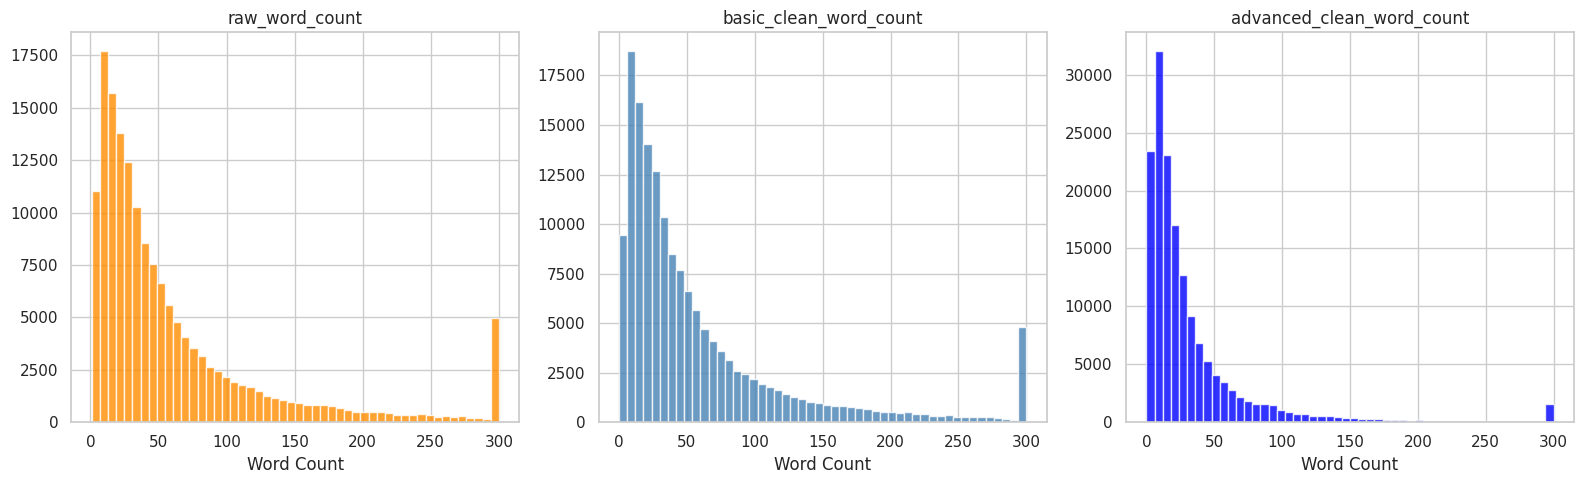

In [261]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [260]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


In [258]:
(train_df['basic_clean'] == train_df['advanced_clean']).sum()

np.int64(3383)

In [259]:
for i in range(5):
    print("RAW:", train_df['comment_text'].iloc[i])
    print("BASIC:", train_df['basic_clean'].iloc[i])
    print("ADVANCED:", train_df['advanced_clean'].iloc[i])
    print("-"*50)

RAW: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27
BASIC: explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now
ADVANCED: explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please remove template talk page since im retired
--------------------------------------------------
RAW: D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)
BASIC: daww he matches this background colour im seemingly stuck with thanks talk january utc
ADVANCED: daww match background colou

# Train  Validation  Test Split

In [267]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [268]:
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')

Train : 127,656  |  Val : 15,957  |  Test : 15,958


# Feature Extraction

1. TF_IDF (for LR and SVM) \
use advanced_clean

In [269]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [272]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])


In [273]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


2. Tokenization & Padding (for LSTM) \
basic_clean

In [278]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences



In [279]:
Vocab_size =30000
max_len= 200

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts) # Corrected method name to texts_to_sequences
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

In [280]:
print('LSTM shape train', X_train_lstm.shape)
print('LSTM shape val', X_val_lstm.shape)
print('LSTM shape test', X_test_lstm.shape)

LSTM shape train (127656, 200)
LSTM shape val (15957, 200)
LSTM shape test (15958, 200)


3. BERT Tokenizer (for BERT) \
raw dataset